# Exploratory Data Analysis (EDA) - Diabetes Risk Prediction

This notebook performs data ingestion, anomaly detection, target distribution check, and feature correlation analysis for the Pima Indians Diabetes dataset.

In [ ]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.utils import load_data

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### 1. Dataset Overview

In [6]:
df = load_data()
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (768, 9)


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 2. Target Variable Analysis (`outcome`)

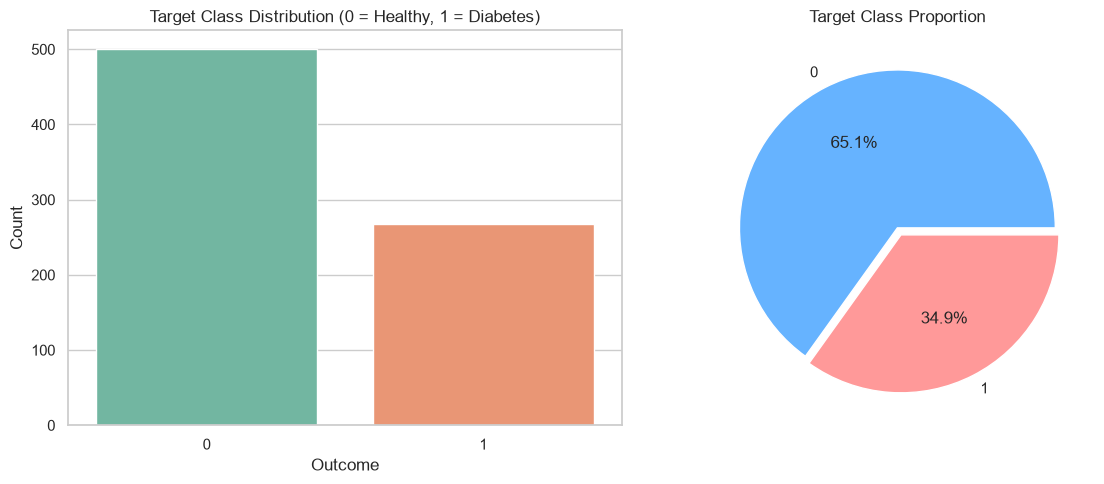

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(
    data=df,
    x="outcome",
    hue="outcome",
    ax=axes[0],
    palette="Set2",
    legend=False,
)
axes[0].set_title("Target Class Distribution (0 = Healthy, 1 = Diabetes)")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Count")

# Pie chart
df["outcome"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[1], colors=["#66b3ff", "#ff9999"], explode=(0, 0.05)
)
axes[1].set_title("Target Class Proportion")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 3. Biological Anomaly & Missing Value Detection

Medical parameters such as `glucose`, `blood_pressure`, `skin_thickness`, `insulin`, and `bmi` cannot naturally be zero. Zero values in these columns represent missing data.

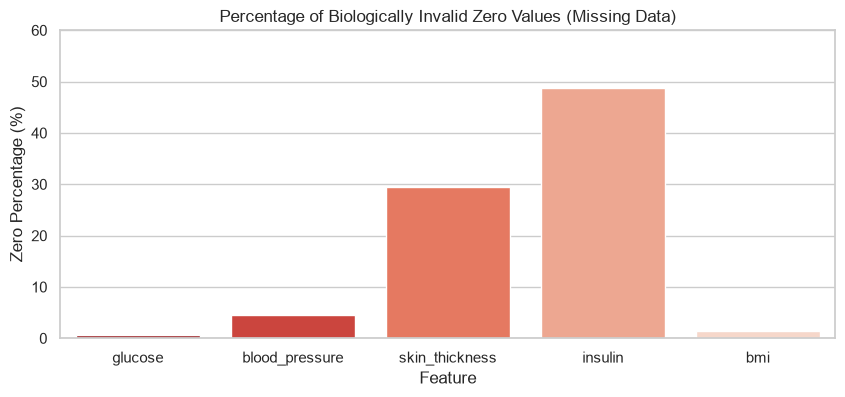

,Feature,Zero Count,Zero Percentage (%)
0,glucose,5,0.651042
1,blood_pressure,35,4.557292
2,skin_thickness,227,29.557292
3,insulin,374,48.697917
4,bmi,11,1.432292


In [13]:
medical_cols = ["glucose", "blood_pressure", "skin_thickness", "insulin", "bmi"]

# Calculate zero value occurrences
zeros_df = (df[medical_cols] == 0).sum().reset_index()
zeros_df.columns = ["Feature", "Zero Count"]
zeros_df["Zero Percentage (%)"] = (zeros_df["Zero Count"] / len(df)) * 100

plt.figure(figsize=(10, 4))
sns.barplot(
    data=zeros_df,
    x="Feature",
    y="Zero Percentage (%)",
    hue="Feature",
    palette="Reds_r",
    legend=False,
)
plt.title("Percentage of Biologically Invalid Zero Values (Missing Data)")
plt.ylim(0, 60)
plt.show()

zeros_df

### 4. Feature Correlation Matrix

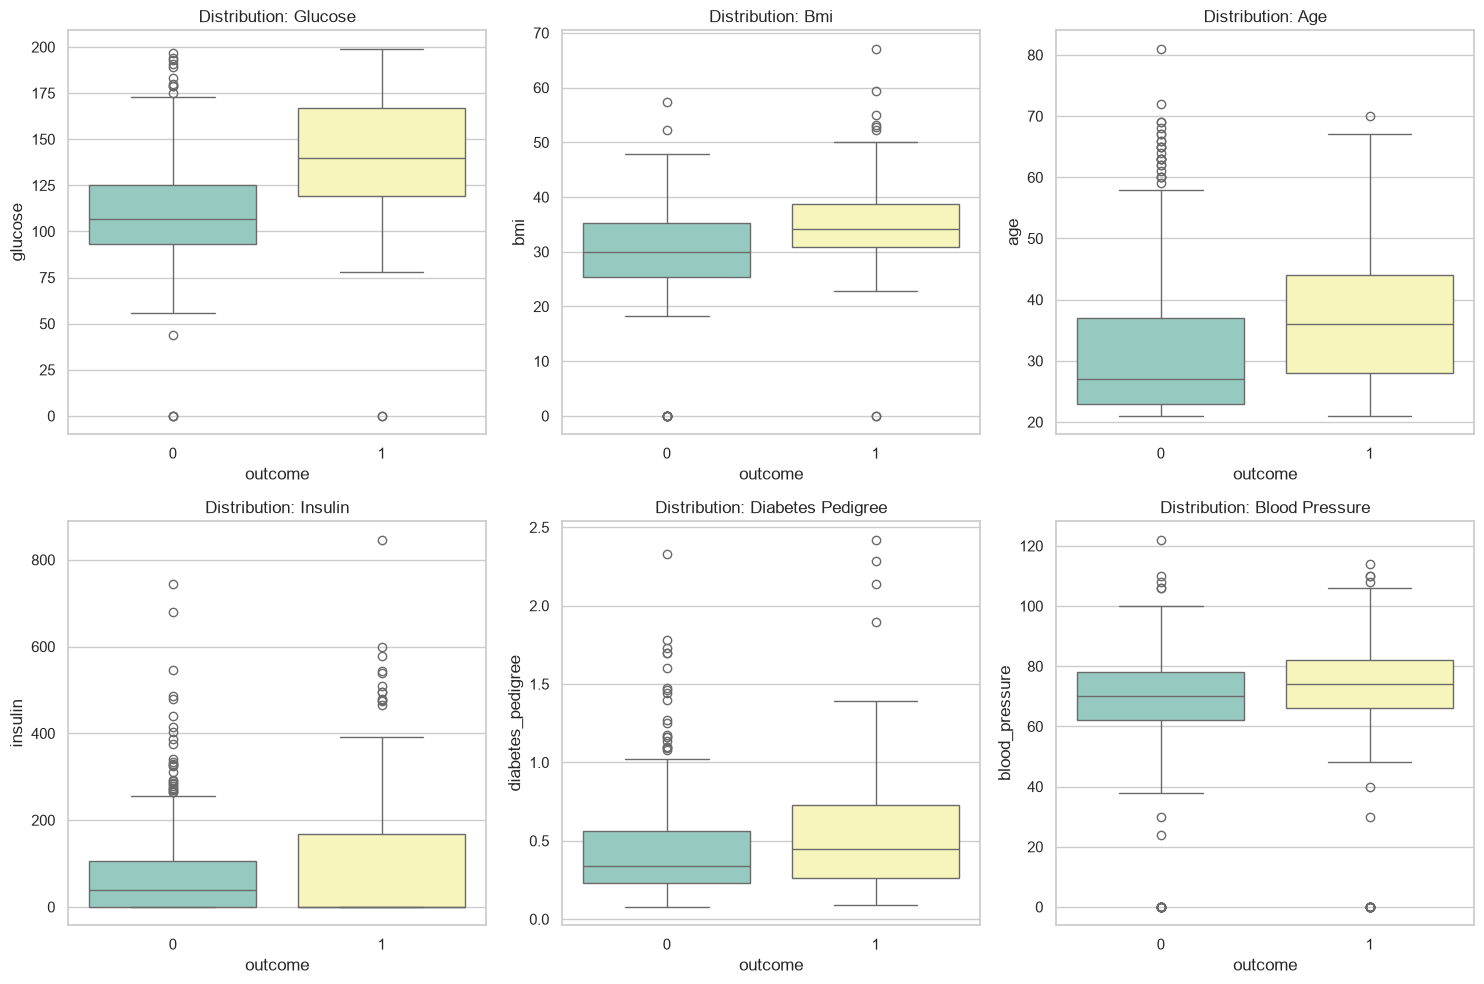

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

features_to_plot = [
    "glucose",
    "bmi",
    "age",
    "insulin",
    "diabetes_pedigree",
    "blood_pressure",
]

for idx, col in enumerate(features_to_plot):
    sns.boxplot(
        data=df,
        x="outcome",
        y=col,
        hue="outcome",
        ax=axes[idx],
        palette="Set3",
        legend=False,
    )
    axes[idx].set_title(f"Distribution: {col.replace('_', ' ').title()}")

plt.tight_layout()
plt.show()